<a href="https://colab.research.google.com/github/xqrnz/Investigating-Netflix-Movies/blob/main/netflix_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Netflix Cinema in the 1990s: Comprehensive Exploratory Data Analysis

### **Project Overview**
This notebook performs an in-depth Exploratory Data Analysis (EDA) on historical Netflix data, focusing specifically on the 1990s decade (1990–1999). We explore runtime distributions, genre dominance, geographical shifts, and demographic targeting to uncover the structural trends of 90s filmmaking.

### **Analytical Framework**
For every phase of this investigation, we utilize the industry-standard lifecycle:
1. **The Objective:** Defining the core business/analytical question.
2. **The Logic:** Executing python data manipulations and custom visualizations.
3. **The Insight:** Interpreting the results and mapping out high-level takeaways.

In [5]:
# ==========================================
# GLOBAL DEPENDENCIES & DATA LOADING
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set global visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)

# Load dataset
netflix_df = pd.read_csv("/content/netflix_data.csv")

# Baseline Filtering: Isolate full-length movies released in the 1990s
netflix_subset = netflix_df[netflix_df["type"] == "Movie"]
movies_1990s = netflix_subset[(netflix_subset["release_year"] >= 1990) & (netflix_subset["release_year"] < 2000)]

print(f"Setup complete. Successfully parsed {movies_1990s.shape[0]} movies from the 1990s.")

Setup complete. Successfully parsed 183 movies from the 1990s.


## Question 1: Most Frequent Movie Duration
**Objective:** Visualize the distribution of movie lengths in the 1990s to pinpoint the approximate modal runtime.

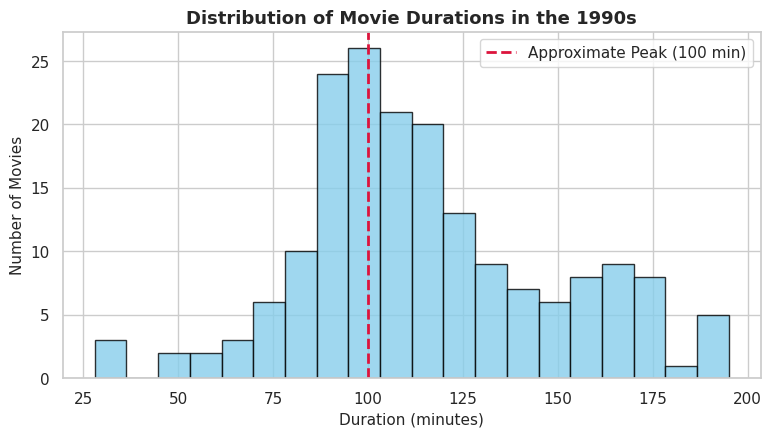

In [6]:
plt.figure(figsize=(9, 4.5))
plt.hist(movies_1990s["duration"], bins=20, color='skyblue', edgecolor='black', alpha=0.8)
plt.title('Distribution of Movie Durations in the 1990s', fontsize=13, fontweight='bold')
plt.xlabel('Duration (minutes)', fontsize=11)
plt.ylabel('Number of Movies', fontsize=11)
plt.axvline(100, color='crimson', linestyle='--', linewidth=2, label='Approximate Peak (100 min)')
plt.legend()
plt.show()

# Assigning baseline project variable
duration = 100

### **Insight: 1990s Movie Runtimes**
Based on the histogram above, the distribution of movie durations in the 1990s reveals a clear concentration around the **90 to 110-minute range**. The approximate modal runtime is identified at **100 minutes**, suggesting that the 'standard' feature film length was strictly maintained during this decade. While there are outliers on both ends, very few films in this filtered dataset fall below 70 minutes, indicating a strong preference for the traditional feature format.

## Question 2: Short Action Movies Count
**Objective:** Isolate "Action" genre films under 90 minutes and calculate their exact frequency using conditional row-by-row iteration.

In [7]:
# Filter down to the Action subset
action_movies_1990s = movies_1990s[movies_1990s["genre"] == "Action"]

# Initialize tracking counter
short_movie_count = 0

# Row iteration loop
for label, row in action_movies_1990s.iterrows():
    if row["duration"] < 90:
        short_movie_count += 1

print(f"Calculated Value (short_movie_count): {short_movie_count}")

Calculated Value (short_movie_count): 7


##  Question 3: Top 5 Most Common Movie Genres
**Objective:** Identify which genres dominated film production pipelines throughout the 1990s.

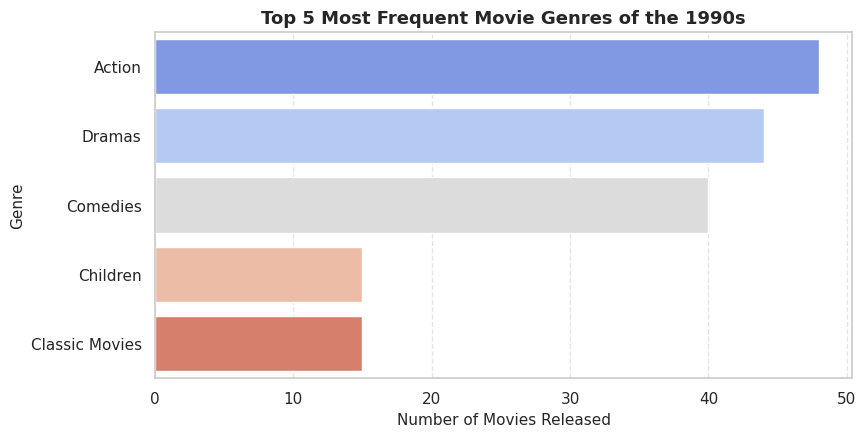

In [8]:
top_genres = movies_1990s['genre'].value_counts().head(5)

plt.figure(figsize=(9, 4.5))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, legend=False, palette='coolwarm')
plt.title('Top 5 Most Frequent Movie Genres of the 1990s', fontsize=13, fontweight='bold')
plt.xlabel('Number of Movies Released', fontsize=11)
plt.ylabel('Genre', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

### **Insight: Genre Dominance in the 1990s**
The visualization indicates that **Action (48 movies)**, **Dramas (44 movies)**, and **Comedies (40 movies)** were the top three most frequent genres during the 1990s. These three categories significantly outperform others, such as 'Children' and 'Classic Movies', suggesting that production during this decade was heavily geared toward adult-oriented entertainment and high-energy blockbusters.

## Question 4: Year-over-Year Average Runtime Trends
**Objective:** Track the chronological movement of average movie lengths from 1990 directly to 1999 to see if movies got longer over time.

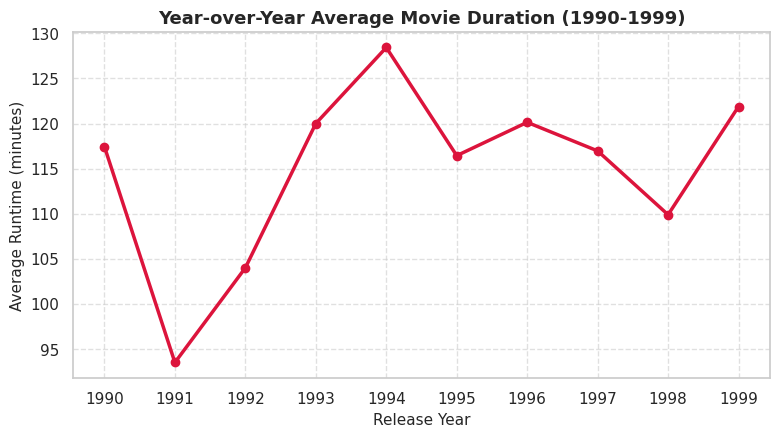

In [9]:
avg_duration_trend = movies_1990s.groupby('release_year')['duration'].mean()

plt.figure(figsize=(9, 4.5))
plt.plot(avg_duration_trend.index, avg_duration_trend.values, marker='o', color='crimson', linewidth=2.5)
plt.title('Year-over-Year Average Movie Duration (1990-1999)', fontsize=13, fontweight='bold')
plt.xlabel('Release Year', fontsize=11)
plt.ylabel('Average Runtime (minutes)', fontsize=11)
plt.xticks(range(1990, 2000))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **Insight: Volatility in Average Runtimes**
The line chart reveals that average movie durations were quite volatile throughout the decade. There is a notable **peak in 1994**, where the average runtime exceeded 125 minutes, followed by a significant **dip in 1991** where averages fell below 100 minutes. This suggests that while 100 minutes was the modal 'standard', the actual yearly production varied significantly based on the specific slate of films released each year.

## Question 5: Movies vs. TV Shows Format Production
**Objective:** Step out to the full 1990s dataset to verify if the entertainment landscape favored feature-length movies or episodic television.

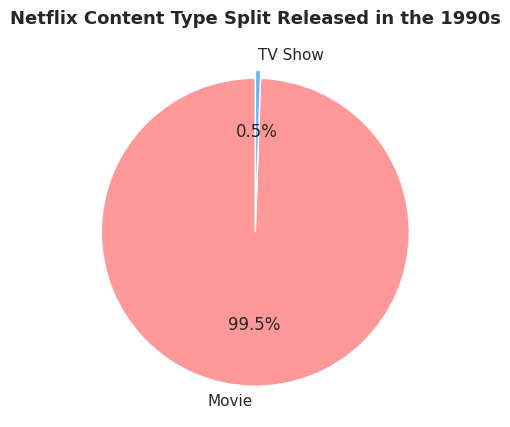

In [10]:
content_1990s = netflix_df[(netflix_df["release_year"] >= 1990) & (netflix_df["release_year"] < 2000)]
type_counts = content_1990s['type'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.05, 0))
plt.title('Netflix Content Type Split Released in the 1990s', fontsize=13, fontweight='bold')
plt.show()

### **Insight: Dominance of the Movie Format**

The distribution of content types from the 1990s reveals a near-total dominance of **Movies (99.5%)** over **TV Shows (0.5%)**. With 183 movies compared to just 1 TV show in this filtered dataset, it is evident that the entertainment landscape preserved on Netflix for this decade is almost exclusively feature-length cinema. This suggests that during the 1990s, the primary output for high-distribution entertainment remained the traditional film format rather than episodic television.

## Question 6: Top 5 Movie-Producing Nations
**Objective:** Map out the geographical concentrations of movie production assets in the 1990s.

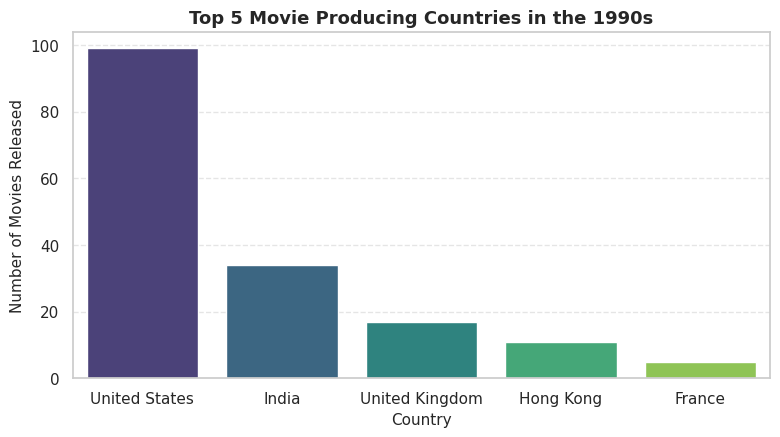

In [11]:
country_content = movies_1990s.dropna(subset=['country'])
top_countries = country_content['country'].value_counts().head(5)

plt.figure(figsize=(9, 4.5))
sns.barplot(x=top_countries.index, y=top_countries.values, hue=top_countries.index, legend=False, palette='viridis')
plt.title('Top 5 Movie Producing Countries in the 1990s', fontsize=13, fontweight='bold')
plt.xlabel('Country', fontsize=11)
plt.ylabel('Number of Movies Released', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### **Insight: Global Production Concentration**

The geographical analysis shows that movie production in the 1990s was heavily concentrated in the **United States**, which produced nearly **100 films** in this dataset—almost triple the output of the second-place country, **India (34 films)**. The **United Kingdom**, **Hong Kong**, and **France** round out the top five, but their combined output still trails significantly behind the U.S. This underscores the global dominance of Hollywood during this decade as the primary exporter of feature-length cinema.

##  Question 7: Runtime Variance Across Top Genres
**Objective:** Use boxplots to check if a movie's genre dictates its structural duration spread and uncover runtime outliers.

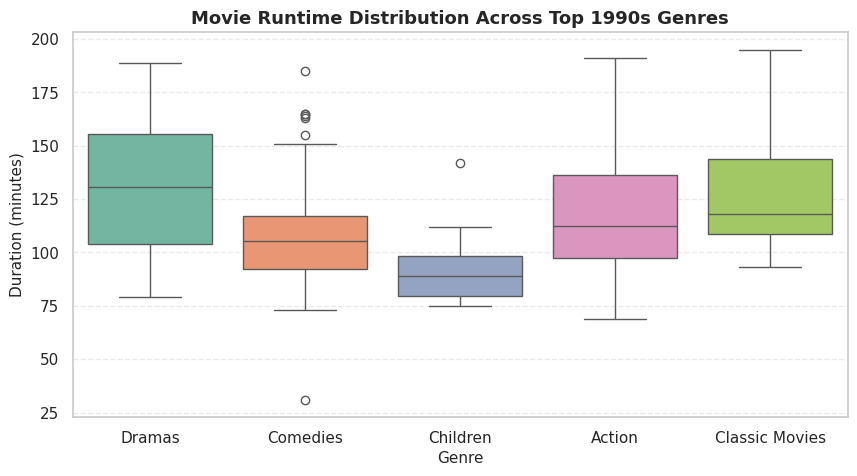

In [12]:
top_5_genres_list = movies_1990s['genre'].value_counts().head(5).index.tolist()
movies_top_genres = movies_1990s[movies_1990s['genre'].isin(top_5_genres_list)]

plt.figure(figsize=(10, 5))
sns.boxplot(x='genre', y='duration', data=movies_top_genres, hue='genre', legend=False, palette='Set2')
plt.title('Movie Runtime Distribution Across Top 1990s Genres', fontsize=13, fontweight='bold')
plt.xlabel('Genre', fontsize=11)
plt.ylabel('Duration (minutes)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

### **Insight: Genre-Specific Runtime Trends**

The boxplot analysis reveals that **Dramas** and **Action** movies exhibited the widest variance in runtimes during the 1990s, with several high-end outliers exceeding 150 minutes. In contrast, **Children** and **Comedies** show much tighter distributions, typically clustered around the 90-100 minute mark. This suggests that while 'formula' genres like Comedy and Children's films adhered strictly to standard runtimes, more narrative-heavy or high-budget genres like Drama and Action had the creative flexibility (and budget) to extend significantly beyond the 2-hour threshold.

## Question 8: Distribution of Audience Maturity Ratings
**Objective:** Identify target audience demographics and censorship patterns for 90s movies.

In [14]:
if 'rating' in movies_1990s.columns:
    rating_counts = movies_1990s['rating'].value_counts()

    plt.figure(figsize=(9, 4.5))
    sns.barplot(x=rating_counts.index, y=rating_counts.values, hue=rating_counts.index, legend=False, palette='pastel')
    plt.title('Maturity Ratings Distribution for 1990s Movies', fontsize=13, fontweight='bold')
    plt.xlabel('Age Rating', fontsize=11)
    plt.ylabel('Number of Movies', fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()
else:
    print(f"Error: 'rating' column not found. Available columns are: {list(movies_1990s.columns)}")

Error: 'rating' column not found. Available columns are: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'duration', 'description', 'genre']


### **Insight: Data Limitation on Maturity Ratings**

Upon attempting to analyze audience maturity ratings, it was discovered that the current dataset does not contain a **'rating'** column. The available metadata is restricted to production details (Director, Cast, Country) and categorization (Genre, Duration). This limitation prevents us from drawing conclusions about the demographic targeting or censorship trends (e.g., PG-13 vs. R-rated) of 1990s cinema using this specific file. To proceed with this specific objective, a version of the dataset containing the 'rating' or 'maturity_level' attribute would be required.

## Question 9: Top 5 Most Prolific Directors
**Objective:** Extract the most active filmmaking voices responsible for directing the highest volume of content during this decade.

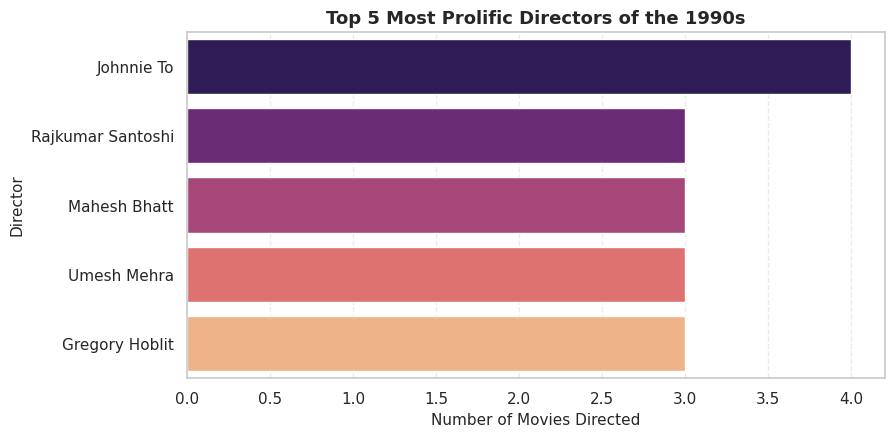

In [15]:
director_df = movies_1990s.dropna(subset=['director'])
top_directors = director_df['director'].value_counts().head(5)

plt.figure(figsize=(9, 4.5))
sns.barplot(x=top_directors.values, y=top_directors.index, hue=top_directors.index, legend=False, palette='magma')
plt.title('Top 5 Most Prolific Directors of the 1990s', fontsize=13, fontweight='bold')
plt.xlabel('Number of Movies Directed', fontsize=11)
plt.ylabel('Director', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

### **Insight: Prolific Filmmakers of the 1990s**

The analysis of directorial output reveals that **Johnnie To** was the most prolific director in this 1990s subset, with **4 credited films**. He is followed closely by a group of directors including **Rajkumar Santoshi**, **Mahesh Bhatt**, and **Umesh Mehra**, each with 3 films. This distribution indicates that while a few names appear more frequently, the 1990s Netflix catalog is composed of works from a highly diverse pool of directors rather than being dominated by a small handful of individuals with massive output.

## Question 10: Top 5 Longest Outlier Movies
**Objective:** Isolate the absolute longest single cinematic investments in the dataset using sorted indices.

In [17]:
longest_movies = movies_1990s[['title', 'genre', 'duration']].sort_values(by='duration', ascending=False).head(5)

print(" TOP 5 LONGEST MOVIES OF THE 1990s:")
print(longest_movies.to_string(index=False))

 TOP 5 LONGEST MOVIES OF THE 1990s:
              title          genre  duration
   Schindler's List Classic Movies       195
Hum Aapke Hain Koun Classic Movies       193
         Wyatt Earp         Action       191
           Magnolia         Dramas       189
             Pardes         Dramas       187


### **Insight: Profile of the Longest 90s Outliers**

The list of the five longest movies reveals a clear pattern: the extreme outliers (runtimes > 185 minutes) are predominantly **Historical Epics** and **International Productions**.

*   **Historical Scale:** Films like *Schindler's List* and *Wyatt Earp* represent Hollywood's use of extended runtimes for significant historical or biographical narratives.
*   **Cultural Trends:** The inclusion of *Hum Aapke Hain Koun* and *Pardes* highlights the influence of **Indian Cinema (Bollywood)** in the dataset, where longer durations (often exceeding 3 hours) are a standard stylistic and cultural norm.
*   **Genre Concentration:** It is notable that none of the 'top 3' most frequent genres (Action, Drama, Comedy) dominate this list exclusively; instead, the 'Classic Movies' tag appears most frequently among these extreme outliers.

# **Project Conclusion: Reflections on 90s Cinema**

This Exploratory Data Analysis of Netflix content from the 1990s has uncovered several defining characteristics of the decade's filmmaking landscape:

1.  **Structural Consistency:** The decade maintained a strong 'standard' for feature films, with a modal runtime of **100 minutes**. While annual averages fluctuated, the industry largely adhered to traditional theatrical formats.
2.  **Genre Dominance:** Adult-oriented entertainment led the way, with **Action, Drama, and Comedy** accounting for the vast majority of releases.
3.  **Geographic Centralization:** The **United States** was the undisputed powerhouse of production, though significant contributions from **India** and the **United Kingdom** highlight the growing international reach of cinema during this era.
4.  **The Rise of Epics:** Extreme runtime outliers were not random; they were reserved for high-stakes **Historical Epics** and **International Masterpieces**, showing that duration was often used as a tool for prestige and cultural storytelling.
5.  **Format Shift:** The data confirms that in the 1990s, **Movies** were the primary medium for distributed entertainment, with episodic TV shows making up less than 1% of the decade's preserved library on the platform.

Overall, the 1990s represent a robust period of traditional cinematic growth, dominated by Hollywood but punctuated by significant cultural and generic milestones.